# Reinforcement Learning Lab: MountainCar using Gymnasium

## Topic

In this lab, we will use **one same environment**: `MountainCar-v0`.

We will apply and compare four learning methods:

1. **Imitation Learning / Behavioural Cloning**
2. **Q-Learning**
3. **REINFORCE**
4. **A2C / Actor-Critic**

## Main idea of the lab

The same problem can be solved using different Reinforcement Learning algorithms.

By using the same MountainCar scenario, students can clearly see:

- Which method learns by copying
- Which method learns using a Q-table
- Which method learns a policy directly
- Which method uses both actor and critic
- How results can be different for the same environment
> Updated notebook: uses the current Gymnasium reset/step API, removes the invalid final code cell, reports success rate, seeds action sampling, scales neural-network inputs, and uses logits for PyTorch categorical policies.


# 1. What is MountainCar?

MountainCar is a small simulation.

A car is stuck in a valley between two hills.

The engine is weak, so the car cannot go directly up the right hill.

The car must first move backward, gain speed, and then move forward to reach the flag.

## Goal

The goal is to reach the flag on the right side.

## State

The environment gives the agent two values:

1. **Position** of the car
2. **Velocity** of the car

## Actions

The agent can choose one of three actions:

| Action Number | Meaning |
|---|---|
| 0 | Push left |
| 1 | Do nothing |
| 2 | Push right |

## Reward

MountainCar usually gives reward `-1` at each step.

So the agent wants to finish in fewer steps.

Example:

- Reward `-100` is better than `-200`
- Because `-100` means the car reached the goal faster

# 2. Install required libraries

Run the following cell only once.

If you are using Google Colab or Jupyter Notebook, this will install the required packages.

In [1]:
# Colab/Jupyter setup. Run once per fresh runtime.
# Gymnasium is the maintained successor of the old `gym` package.
!uv pip install -U "gymnasium[classic-control]" torch numpy matplotlib -q


error: failed to remove file `D:\Reading_Resources\Master\RIL\lab\.venv\Lib\site-packages\numpy.libs/libscipy_openblas64_-63c857e738469261263c764a36be9436.dll`: Access is denied. (os error 5)


# 3. Import libraries

We will use:

- `gymnasium` for the MountainCar environment
- `numpy` for numerical operations
- `torch` for neural networks
- `matplotlib` for graphs

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from importlib.metadata import version, PackageNotFoundError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

print("Libraries imported successfully.")
print("Gymnasium:", package_version("gymnasium"))
print("Torch:", torch.__version__)
print("Device:", DEVICE)


Libraries imported successfully.
Gymnasium: 1.3.0
Torch: 2.12.0+cpu
Device: cpu


# 4. Create the MountainCar environment

Here we create the environment using Gymnasium.

Important Gymnasium format:

```python
obs, info = env.reset()
obs, reward, terminated, truncated, info = env.step(action)
```

`terminated` means the task ended successfully or naturally.

`truncated` means the episode stopped because the maximum time limit was reached.

In [3]:
env = gym.make("MountainCar-v0")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)

obs, info = env.reset(seed=SEED)
print("Initial observation:", obs)
print("Position:", obs[0])
print("Velocity:", obs[1])

env.close()

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Number of actions: 3
Initial observation: [-0.4452088  0.       ]
Position: -0.4452088
Velocity: 0.0


# 5. Helper functions

We will use these functions many times.

## Why helper functions?

They make the code cleaner.

We will create:

1. A reward shaping function
2. An evaluation function with success rate
3. A graph plotting function
4. Observation scaling for neural-network methods

## Reward shaping

MountainCar reward is difficult because it gives `-1` almost all the time.

To help learning during training, we add a small shaped reward.

But for final evaluation, we still use the original environment reward.


In [4]:
def make_env(render=False):
    """Create MountainCar with the current Gymnasium API."""
    render_mode = "human" if render else None
    return gym.make("MountainCar-v0", render_mode=render_mode)


def scale_obs(obs):
    """Scale MountainCar observations to a smaller range for neural networks."""
    obs = np.asarray(obs, dtype=np.float32)
    low = np.array([-1.2, -0.07], dtype=np.float32)
    high = np.array([0.6, 0.07], dtype=np.float32)
    return 2.0 * (obs - low) / (high - low) - 1.0


def shaped_reward(obs, reward, terminated=False):
    """
    Training-only reward shaping.

    Final evaluation still uses the original environment reward.
    The terminal bonus helps the learner distinguish reaching the flag
    from merely surviving until the 200-step time limit.
    """
    position, velocity = obs
    progress_bonus = 5.0 * (position + 0.5)
    speed_bonus = 50.0 * abs(velocity)
    goal_bonus = 100.0 if terminated else 0.0
    return reward + progress_bonus + speed_bonus + goal_bonus


def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")


def plot_rewards(rewards, title, window=20):
    plt.figure(figsize=(8, 4))
    plt.plot(rewards, label="Episode reward")
    if len(rewards) >= window:
        ma = moving_average(rewards, window)
        plt.plot(range(window - 1, len(rewards)), ma, label=f"{window}-episode moving average")
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Original environment reward")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_agent(agent_function, episodes=20, render=False, start_seed=10_000):
    """
    Evaluate with original rewards only.

    A MountainCar episode is successful when `terminated=True`.
    If `truncated=True`, the 200-step time limit was reached.
    """
    test_env = make_env(render=render)
    rewards = []
    steps = []
    successes = []

    for ep in range(episodes):
        obs, info = test_env.reset(seed=start_seed + ep)
        total_reward = 0.0
        step_count = 0

        while True:
            action = int(agent_function(obs))
            obs, reward, terminated, truncated, info = test_env.step(action)
            total_reward += reward
            step_count += 1

            if terminated or truncated:
                rewards.append(total_reward)
                steps.append(step_count)
                successes.append(bool(terminated))
                break

    test_env.close()
    return {
        "avg_reward": float(np.mean(rewards)),
        "success_rate": float(np.mean(successes)),
        "avg_steps": float(np.mean(steps)),
        "rewards": rewards,
        "steps": steps,
        "successes": successes,
    }


def print_evaluation(name, evaluation):
    print(f"{name} average reward: {evaluation['avg_reward']:.2f}")
    print(f"{name} success rate: {evaluation['success_rate'] * 100:.1f}%")
    print(f"{name} average steps: {evaluation['avg_steps']:.1f}")
    print("Rewards:", evaluation["rewards"])


print("Helper functions created.")


Helper functions created.


# Part A: Behavioural Cloning / Imitation Learning

## Simple meaning

Behavioural Cloning means:

> The agent learns by copying an expert.

This is similar to supervised learning.

We first create expert examples:

```text
state → expert action
```

Then we train a neural network to predict the expert action.

## Important idea

Behavioural Cloning does not learn from reward directly.

It learns from examples.

# 6. Create expert data

For this simple lab, we create a rule-based expert.

The expert is not perfect, but it gives useful actions.

Rule idea:

- If velocity is positive, push right
- If velocity is negative, push left

This helps the car build momentum.

In [5]:
def expert_policy(obs):
    """
    A simple hand-coded MountainCar teacher.

    It pushes in the direction of velocity to build momentum.
    This is a heuristic expert, not an optimal controller.
    """
    position, velocity = obs
    return 2 if velocity >= 0 else 0


def collect_expert_data(episodes=120):
    env = make_env()
    env.action_space.seed(SEED)
    states = []
    actions = []

    for ep in range(episodes):
        obs, info = env.reset(seed=SEED + ep)

        while True:
            action = expert_policy(obs)
            states.append(scale_obs(obs))
            actions.append(action)

            obs, reward, terminated, truncated, info = env.step(action)

            if terminated or truncated:
                break

    env.close()
    return np.array(states, dtype=np.float32), np.array(actions, dtype=np.int64)


expert_states, expert_actions = collect_expert_data(episodes=120)
expert_eval = evaluate_agent(expert_policy, episodes=20)

print("Expert states shape:", expert_states.shape)
print("Expert actions shape:", expert_actions.shape)
print("Example scaled state:", expert_states[0])
print("Example action:", expert_actions[0])
print_evaluation("Heuristic expert", expert_eval)


Expert states shape: (14410, 2)
Expert actions shape: (14410,)
Example scaled state: [-0.1613431  0.       ]
Example action: 2
Heuristic expert average reward: -120.20
Heuristic expert success rate: 100.0%
Heuristic expert average steps: 120.2
Rewards: [-124.0, -122.0, -122.0, -122.0, -121.0, -115.0, -114.0, -121.0, -123.0, -124.0, -114.0, -124.0, -114.0, -124.0, -114.0, -124.0, -114.0, -123.0, -123.0, -122.0]


# 7. Behavioural Cloning neural network

This network receives:

```text
position, velocity
```

and predicts one of three actions:

```text
0, 1, or 2
```

In [6]:
class BehaviourCloningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)  # raw logits; do not apply softmax before CrossEntropyLoss
        )

    def forward(self, x):
        return self.model(x)


bc_model = BehaviourCloningNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bc_model.parameters(), lr=0.001)

print(bc_model)


BehaviourCloningNet(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


# 8. Train Behavioural Cloning model

We train it like a normal classification model.

Input:

```text
state
```

Target:

```text
expert action
```

Epoch 25, Loss: 0.0188
Epoch 50, Loss: 0.0098
Epoch 75, Loss: 0.0069
Epoch 100, Loss: 0.0059
Epoch 125, Loss: 0.0051
Epoch 150, Loss: 0.0037


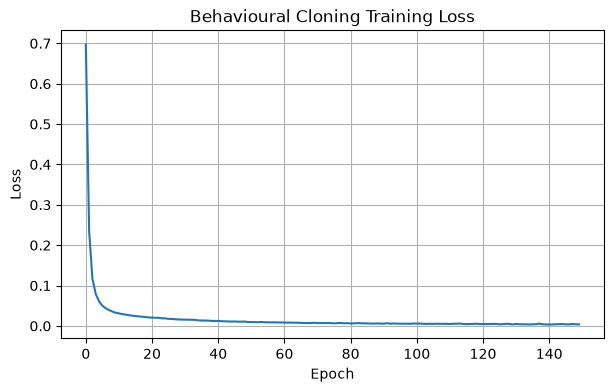

In [7]:
X = torch.tensor(expert_states, dtype=torch.float32)
y = torch.tensor(expert_actions, dtype=torch.long)

loader = DataLoader(
    TensorDataset(X, y),
    batch_size=256,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

bc_losses = []

for epoch in range(150):
    epoch_losses = []

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()
        logits = bc_model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    bc_losses.append(float(np.mean(epoch_losses)))

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}, Loss: {bc_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(bc_losses)
plt.title("Behavioural Cloning Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# 9. Evaluate Behavioural Cloning

Now we test how well the cloned policy performs.

In [21]:
def bc_agent(obs):
    bc_model.eval()
    with torch.no_grad():
        obs_tensor = torch.tensor(scale_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits = bc_model(obs_tensor)
        action = torch.argmax(logits, dim=1).item()
    return action


bc_eval = evaluate_agent(bc_agent, episodes=3, render= True)
bc_avg_reward = bc_eval["avg_reward"]
print_evaluation("Behavioural Cloning", bc_eval)


Behavioural Cloning average reward: -122.33
Behavioural Cloning success rate: 100.0%
Behavioural Cloning average steps: 122.3
Rewards: [-124.0, -121.0, -122.0]


# Part B: Q-Learning

## Simple meaning

Q-Learning learns a table.

The table tells the agent:

```text
In this state, which action is best?
```

## Problem

MountainCar state values are continuous:

- position can be many decimal values
- velocity can be many decimal values

A table cannot store infinite decimal states.

So we divide the state space into bins.

This is called **discretization**.

# 10. Discretize the state space

We convert continuous values into discrete bins.

Example:

```text
position = -0.45 → bin 8
velocity = 0.02 → bin 15
```

Then the Q-table can use these bin numbers.

In [9]:
# Number of bins for each state variable: position and velocity
num_bins = np.array([20, 20])

# Lower and upper bounds of observation space
state_low = np.array([-1.2, -0.07], dtype=np.float32)
state_high = np.array([0.6, 0.07], dtype=np.float32)

# Width of each bin
bin_width = (state_high - state_low) / num_bins

def discretize_state(state):
    """
    Convert a continuous state into a discrete state index.
    """
    discrete_state = ((state - state_low) / bin_width).astype(int)
    # clip indices to range [0, 19]
    discrete_state = np.clip(discrete_state, 0, num_bins - 1)
    return tuple(discrete_state)

# Test discretization on a sample state
print("Sample continuous state: [-0.4452088  0.       ]")
print("Sample discrete state:", discretize_state(np.array([-0.4452088, 0.0])))


Sample continuous state: [-0.4452088  0.       ]
Sample discrete state: (np.int64(8), np.int64(10))


# 11. Initialize Q-Table and Train Q-Learning

We initialize the Q-table with small negative values to encourage early exploration, and then run tabular Q-learning using epsilon-greedy exploration.

Episode  1000 | Avg Reward: -200.00 | Avg Steps: 200.0 | Epsilon: 0.606
Episode  2000 | Avg Reward: -199.87 | Avg Steps: 199.9 | Epsilon: 0.368
Episode  3000 | Avg Reward: -196.13 | Avg Steps: 196.1 | Epsilon: 0.223
Episode  4000 | Avg Reward: -185.30 | Avg Steps: 185.3 | Epsilon: 0.135
Episode  5000 | Avg Reward: -176.55 | Avg Steps: 176.5 | Epsilon: 0.082
Episode  6000 | Avg Reward: -174.69 | Avg Steps: 174.7 | Epsilon: 0.050
Episode  7000 | Avg Reward: -162.30 | Avg Steps: 162.3 | Epsilon: 0.030
Episode  8000 | Avg Reward: -158.66 | Avg Steps: 158.7 | Epsilon: 0.018
Episode  9000 | Avg Reward: -166.56 | Avg Steps: 166.6 | Epsilon: 0.011
Episode 10000 | Avg Reward: -137.56 | Avg Steps: 137.6 | Epsilon: 0.010


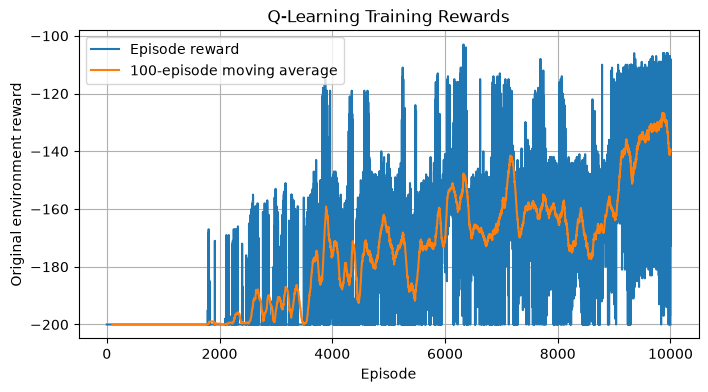

In [10]:
# Initialize Q-table shape: position bins x velocity bins x number of actions
q_table_shape = (num_bins[0], num_bins[1], 3)
q_table = np.random.uniform(low=-2.0, high=0.0, size=q_table_shape)

# Q-Learning Hyperparameters
q_episodes = 10000
max_steps = 200
learning_rate = 0.1
discount_factor = 0.99

# Exploration parameters
epsilon = 1.0
epsilon_decay = 0.9995
min_epsilon = 0.01

q_episode_rewards = []
q_steps_per_episode = []

env = make_env()
env.action_space.seed(SEED)

for episode in range(q_episodes):
    state, info = env.reset(seed=SEED + episode)
    discrete_state = discretize_state(state)
    total_reward = 0.0

    for step in range(max_steps):
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[discrete_state])

        next_state, reward, terminated, truncated, info = env.step(action)
        next_discrete_state = discretize_state(next_state)
        done = terminated or truncated

        current_q = q_table[discrete_state + (action,)]

        if terminated:
            target_q = 0.0  # Reached the goal
        else:
            max_future_q = np.max(q_table[next_discrete_state])
            target_q = reward + discount_factor * max_future_q

        # Q-learning update
        q_table[discrete_state + (action,)] = current_q + learning_rate * (target_q - current_q)

        discrete_state = next_discrete_state
        total_reward += reward

        if done:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    q_episode_rewards.append(total_reward)
    q_steps_per_episode.append(step + 1)

    if (episode + 1) % 1000 == 0:
        avg_reward = np.mean(q_episode_rewards[-1000:])
        avg_steps = np.mean(q_steps_per_episode[-1000:])
        print(f"Episode {episode+1:5d} | Avg Reward: {avg_reward:7.2f} | Avg Steps: {avg_steps:5.1f} | Epsilon: {epsilon:.3f}")

env.close()
plot_rewards(q_episode_rewards, "Q-Learning Training Rewards", window=100)


# 12. Evaluate Q-Learning

We test our Q-learning table deterministically (greedy choices only) over 20 evaluation episodes.

In [22]:
def q_agent(obs):
    discrete_state = discretize_state(obs)
    return np.argmax(q_table[discrete_state])

q_eval = evaluate_agent(q_agent, episodes=3, render=True)
q_avg_reward = q_eval["avg_reward"]
print_evaluation("Q-Learning", q_eval)


Q-Learning average reward: -169.33
Q-Learning success rate: 100.0%
Q-Learning average steps: 169.3
Rewards: [-174.0, -154.0, -180.0]


# Part C: REINFORCE Algorithm

## Simple meaning

REINFORCE learns a policy directly.

A policy means:

```text
Given a state, what action should I take?
```

The neural network gives probabilities for actions.

Example:

```text
Push left: 20%
Do nothing: 10%
Push right: 70%
```

The agent samples an action from these probabilities.

If the episode result is good, the algorithm increases the probability of the actions taken.

# 13. Policy network for REINFORCE

The network input is:

```text
position, velocity
```

The output is:

```text
probabilities for 3 actions
```

In [18]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, state):
        logits = self.model(state)
        return logits

    def get_action(self, state, deterministic=False):
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits = self.forward(state_tensor)
        probs = torch.softmax(logits, dim=-1)

        if deterministic:
            action = torch.argmax(probs, dim=-1)
            log_prob = torch.log(probs[0, action] + 1e-8)
            entropy = Categorical(probs).entropy()
        else:
            distribution = Categorical(probs)
            action = distribution.sample()
            log_prob = distribution.log_prob(action)
            entropy = distribution.entropy()

        return action.item(), log_prob.squeeze(), entropy.squeeze()


# 14. Train REINFORCE

For each episode:

1. Run the policy
2. Store log probabilities of selected actions
3. Store rewards
4. Calculate discounted return
5. Update policy

## Discounted return

A reward received earlier is usually more important than a reward far in the future.

That is why we use discount factor `gamma`.

In [19]:
def compute_discounted_returns(rewards, gamma=0.99):
    returns = []
    G = 0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def train_reinforce_until_success(
    max_episodes=3000,
    gamma=0.99,
    learning_rate=0.0007,
    entropy_beta=0.01,
    target_successes_in_last_50=5,
    print_every=100,
    save_path="best_reinforce_mountaincar.pth"
):
    env = gym.make("MountainCar-v0")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, action_dim).to(DEVICE)
    optimizer = optim.Adam(policy.parameters(), lr=learning_rate)

    original_rewards_history = []
    shaped_rewards_history = []
    success_history = []

    best_original_reward = -9999
    best_success_count = 0

    for episode in range(1, max_episodes + 1):
        state, info = env.reset(seed=SEED + episode)

        log_probs = []
        entropies = []
        shaped_rewards = []
        original_rewards = []

        terminated = False
        truncated = False

        while not (terminated or truncated):
            scaled_state = scale_obs(state)
            action, log_prob, entropy = policy.get_action(scaled_state, deterministic=False)
            next_state, original_reward, terminated, truncated, info = env.step(action)

            reward_shaping = shaped_reward(next_state, original_reward, terminated)

            log_probs.append(log_prob)
            entropies.append(entropy)
            shaped_rewards.append(reward_shaping)
            original_rewards.append(original_reward)

            state = next_state

        total_original_reward = sum(original_rewards)
        total_shaped_reward = sum(shaped_rewards)
        success = 1 if state[0] >= 0.5 else 0

        original_rewards_history.append(total_original_reward)
        shaped_rewards_history.append(total_shaped_reward)
        success_history.append(success)

        # compute REINFORCE loss
        returns = compute_discounted_returns(shaped_rewards, gamma=gamma)
        log_probs_tensor = torch.stack(log_probs)
        entropies_tensor = torch.stack(entropies)

        policy_loss = -(log_probs_tensor * returns.to(DEVICE)).sum()
        entropy_loss = -entropy_beta * entropies_tensor.sum()
        loss = policy_loss + entropy_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()

        # save best model
        recent_successes = sum(success_history[-50:])
        if total_original_reward > best_original_reward or recent_successes > best_success_count:
            best_original_reward = total_original_reward
            best_success_count = recent_successes
            torch.save(policy.state_dict(), save_path)

        if episode % print_every == 0:
            avg_original = np.mean(original_rewards_history[-50:])
            avg_shaped = np.mean(shaped_rewards_history[-50:])
            recent_successes = sum(success_history[-50:])
            print(
                f"Episode {episode:4d} | "
                f"Avg original reward: {avg_original:7.2f} | "
                f"Avg shaped reward: {avg_shaped:7.2f} | "
                f"Successes in last 50: {recent_successes}"
            )

        # early stop when success target is hit
        if episode >= 200 and sum(success_history[-50:]) >= target_successes_in_last_50:
            print("Training stopped early because the agent reached the success target.")
            print(f"Successes in last 50 episodes: {sum(success_history[-50:])}")
            break

    env.close()
    policy.load_state_dict(torch.load(save_path, map_location="cpu"))
    print("Training completed. Best model loaded.")
    return policy, original_rewards_history, shaped_rewards_history, success_history


reinforce_policy, reinforce_original, reinforce_shaped, reinforce_success = train_reinforce_until_success(
    max_episodes=3000,
    target_successes_in_last_50=5,
    print_every=100
)
plot_rewards(reinforce_original, "REINFORCE Training Rewards", window=100)


Episode  100 | Avg original reward: -200.00 | Avg shaped reward: -175.85 | Successes in last 50: 0
Episode  200 | Avg original reward: -200.00 | Avg shaped reward: -151.00 | Successes in last 50: 0
Episode  300 | Avg original reward: -200.00 | Avg shaped reward: -134.82 | Successes in last 50: 0
Episode  400 | Avg original reward: -200.00 | Avg shaped reward:  -73.50 | Successes in last 50: 0
Episode  500 | Avg original reward: -200.00 | Avg shaped reward:  -33.43 | Successes in last 50: 0
Episode  600 | Avg original reward: -200.00 | Avg shaped reward:  -29.19 | Successes in last 50: 0
Episode  700 | Avg original reward: -200.00 | Avg shaped reward:  -22.93 | Successes in last 50: 0
Episode  800 | Avg original reward: -200.00 | Avg shaped reward:  -18.65 | Successes in last 50: 0
Episode  900 | Avg original reward: -200.00 | Avg shaped reward:  -16.58 | Successes in last 50: 0
Episode 1000 | Avg original reward: -200.00 | Avg shaped reward:    2.50 | Successes in last 50: 0


KeyboardInterrupt: 

# 15. Evaluate REINFORCE

During evaluation, we choose the action with highest probability.

In [23]:
def reinforce_agent(obs):
    action, _, _ = reinforce_policy.get_action(scale_obs(obs), deterministic=True)
    return action

reinforce_eval = evaluate_agent(reinforce_agent, episodes=3, render=True)
reinforce_avg_reward = reinforce_eval["avg_reward"]
print_evaluation("REINFORCE", reinforce_eval)


NameError: name 'reinforce_policy' is not defined

# Part D: A2C / Actor-Critic

## Simple meaning

A2C means **Advantage Actor-Critic**.

It has two parts:

| Part | Meaning |
|---|---|
| Actor | Chooses the action |
| Critic | Judges how good the state is |

## Why use critic?

REINFORCE can be unstable because it only uses total episode reward.

A2C uses a critic to guide learning more smoothly.

## Advantage

Advantage means:

```text
How much better was this action than expected?
```

If advantage is positive, the action was better than expected.

If advantage is negative, the action was worse than expected.

# 16. Actor-Critic network

This network has shared layers and two heads:

1. Actor head: action probabilities
2. Critic head: state value

In [27]:
class ActorCriticNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        self.actor = nn.Linear(64, 3)  # logits
        self.critic = nn.Linear(64, 1)

    def forward(self, x):
        features = self.shared(x)
        action_logits = self.actor(features)
        state_value = self.critic(features).squeeze(-1)
        return action_logits, state_value


a2c_model = ActorCriticNetwork().to(DEVICE)
a2c_optimizer = optim.Adam(a2c_model.parameters(), lr=0.001)

print(a2c_model)


ActorCriticNetwork(
  (shared): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (actor): Linear(in_features=64, out_features=3, bias=True)
  (critic): Linear(in_features=64, out_features=1, bias=True)
)


# 17. Train A2C

For each step:

1. Actor chooses action
2. Environment gives reward and next state
3. Critic estimates current state value
4. Critic estimates next state value
5. Calculate advantage
6. Update actor and critic

Episode 100, Avg reward(last 100): -200.0, Success(last 100): 0.0%
Episode 200, Avg reward(last 100): -182.9, Success(last 100): 23.0%
Episode 300, Avg reward(last 100): -161.5, Success(last 100): 49.0%
Episode 400, Avg reward(last 100): -200.0, Success(last 100): 0.0%
Episode 500, Avg reward(last 100): -200.0, Success(last 100): 0.0%
Episode 600, Avg reward(last 100): -200.0, Success(last 100): 0.0%
Episode 700, Avg reward(last 100): -200.0, Success(last 100): 0.0%
Episode 800, Avg reward(last 100): -200.0, Success(last 100): 0.0%


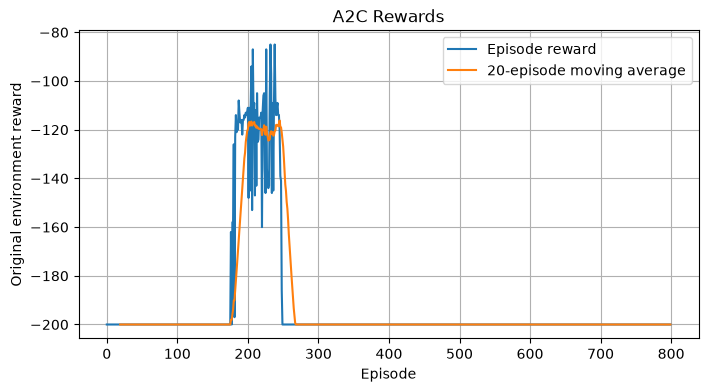

In [28]:
env = make_env()
env.action_space.seed(SEED)
a2c_rewards = []
a2c_successes = []
a2c_episodes = 800
gamma = 0.99

for ep in range(a2c_episodes):
    obs, info = env.reset(seed=SEED + ep)
    total_reward = 0.0

    while True:
        obs_tensor = torch.tensor(scale_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)

        action_logits, state_value = a2c_model(obs_tensor)
        distribution = Categorical(logits=action_logits)
        action = distribution.sample()

        next_obs, reward, terminated, truncated, info = env.step(action.item())
        train_reward = shaped_reward(next_obs, reward, terminated)
        done = terminated or truncated

        next_obs_tensor = torch.tensor(scale_obs(next_obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            _, next_state_value = a2c_model(next_obs_tensor)
            bootstrap_value = 0.0 if done else gamma * next_state_value.item()
            target_value = torch.tensor([train_reward + bootstrap_value], dtype=torch.float32, device=DEVICE)

        advantage = target_value - state_value

        actor_loss = -distribution.log_prob(action) * advantage.detach()
        critic_loss = advantage.pow(2)
        entropy_loss = -0.01 * distribution.entropy()
        loss = actor_loss + 0.5 * critic_loss + entropy_loss

        a2c_optimizer.zero_grad()
        loss.mean().backward()
        torch.nn.utils.clip_grad_norm_(a2c_model.parameters(), max_norm=1.0)
        a2c_optimizer.step()

        total_reward += reward
        obs = next_obs

        if done:
            break

    a2c_rewards.append(total_reward)
    a2c_successes.append(float(terminated))

    if (ep + 1) % 100 == 0:
        recent_success = np.mean(a2c_successes[-100:]) * 100
        recent_reward = np.mean(a2c_rewards[-100:])
        print(f"Episode {ep+1}, Avg reward(last 100): {recent_reward:.1f}, Success(last 100): {recent_success:.1f}%")

env.close()

plot_rewards(a2c_rewards, "A2C Rewards")


# 18. Evaluate A2C

During evaluation, we select the action with highest probability.

In [29]:
def a2c_agent(obs):
    a2c_model.eval()
    with torch.no_grad():
        obs_tensor = torch.tensor(scale_obs(obs), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value = a2c_model(obs_tensor)
        action = torch.argmax(logits, dim=1).item()
    return action


a2c_eval = evaluate_agent(a2c_agent, episodes=3, render=True)
a2c_avg_reward = a2c_eval["avg_reward"]
print_evaluation("A2C", a2c_eval)


A2C average reward: -200.00
A2C success rate: 0.0%
A2C average steps: 200.0
Rewards: [-200.0, -200.0, -200.0]


# 19. Final comparison

Now we compare all four methods using the same environment.

Remember:

In MountainCar, reward is negative.

So:

```text
-100 is better than -200
```

because the agent reached the goal faster.

Final Comparison
------------------------------------------------------------------------
Algorithm                   Avg Reward    Success Rate    Avg Steps
------------------------------------------------------------------------
Behavioural Cloning            -120.20          100.0%        120.2
Q-Learning                     -150.20           95.0%        150.2
REINFORCE                      -200.00            0.0%        200.0
A2C                            -200.00            0.0%        200.0


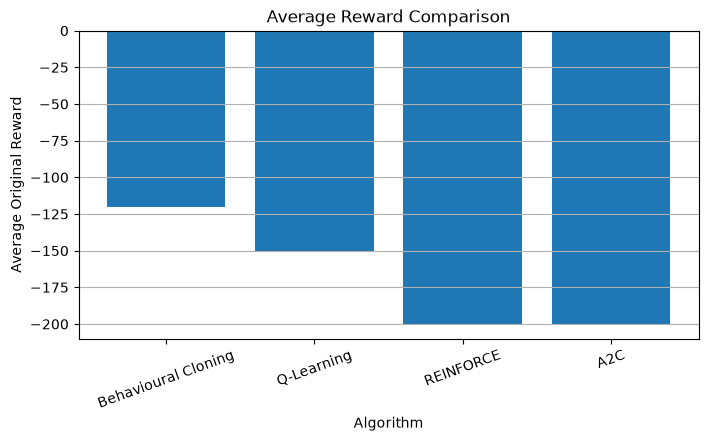

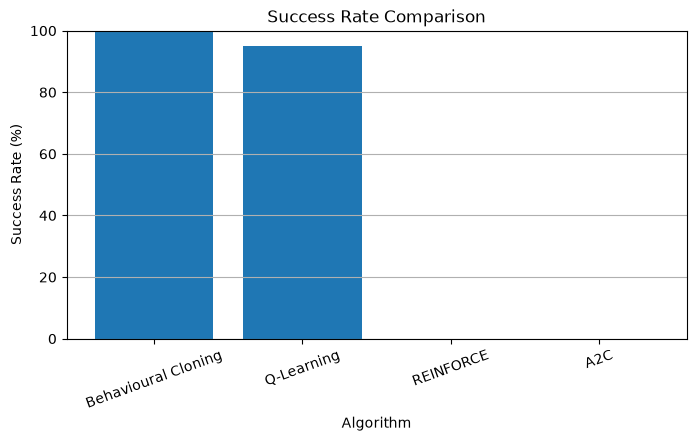

In [18]:
results = {
    "Behavioural Cloning": bc_eval,
    "Q-Learning": q_eval,
    "REINFORCE": reinforce_eval,
    "A2C": a2c_eval,
}

print("Final Comparison")
print("-" * 72)
print(f"{'Algorithm':25s} {'Avg Reward':>12s} {'Success Rate':>15s} {'Avg Steps':>12s}")
print("-" * 72)

for name, evaluation in results.items():
    print(
        f"{name:25s} "
        f"{evaluation['avg_reward']:12.2f} "
        f"{evaluation['success_rate'] * 100:14.1f}% "
        f"{evaluation['avg_steps']:12.1f}"
    )

names = list(results.keys())
avg_rewards = [results[name]["avg_reward"] for name in names]
success_rates = [results[name]["success_rate"] * 100 for name in names]

plt.figure(figsize=(8, 4))
plt.bar(names, avg_rewards)
plt.title("Average Reward Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Average Original Reward")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, success_rates)
plt.title("Success Rate Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()


# 20. Simple explanation of results

The result may be different each time because Reinforcement Learning includes randomness.

But usually students should observe these points:

## Behavioural Cloning

- Learns from expert examples
- Fast to train
- Quality depends on the expert
- If expert is weak, model will also be weak

## Q-Learning

- Learns using a Q-table
- Good for small discrete state spaces
- MountainCar has continuous states, so we used bins
- Performance depends on number of bins and training episodes

## REINFORCE

- Learns a policy directly
- Uses neural network
- Can be unstable
- Needs many episodes

## A2C

- Uses actor and critic
- Actor selects actions
- Critic gives feedback
- Usually more stable than REINFORCE

# 21. Student discussion questions

Ask students these questions after running the lab:

1. Which algorithm gave the best average reward?
2. Which algorithm was easiest to understand?
3. Why does Behavioural Cloning depend on expert data?
4. Why did Q-Learning need discretization?
5. Why can REINFORCE be unstable?
6. How does the critic help in A2C?
7. Why is `-100` better than `-200` in MountainCar?
8. What could we change to improve performance?

# 22. Mini assignment

Students can try:

1. Increase training episodes
2. Change learning rate
3. Change number of Q-Learning bins
4. Remove reward shaping and compare
5. Try another Gymnasium environment such as `CartPole-v1`

# 23. Final summary

In this lab, we used the same MountainCar environment and applied four learning approaches.

| Algorithm | Main Idea |
|---|---|
| Behavioural Cloning | Copy expert actions |
| Q-Learning | Learn best action values |
| REINFORCE | Learn policy using rewards |
| A2C | Actor chooses, critic evaluates |

This helps students understand that different algorithms can solve the same problem in different ways.

# Notes on expected results

MountainCar is intentionally difficult because the default reward is sparse: the agent receives `-1` every step until it reaches the flag or hits the 200-step time limit.

If an algorithm still gets an average reward near `-200`, it did not reach the flag during evaluation. That is not a software-version problem by itself; it means the current hyperparameters, reward shaping, exploration, or training time were not enough.

For a short classroom lab, Q-Learning and Behavioural Cloning usually provide the clearest comparison. REINFORCE and A2C can need more tuning or more episodes on this environment.
